[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/01_eda.ipynb)

# 01 — Exploratory Data Analysis

**Purpose.** Understand what `00_simulation.ipynb` produced well enough to specify
notebook 02: what the columns mean, how they are distributed, where they are
missing, how records are grouped, and which values are impossible.

**Inputs.** The four simulation artifacts at the paths in `cfg.simulation.output`
— read-only, never modified.

**Outputs.** *Insights, not artifacts.* Nothing here writes to `data/` or
`models/`. The deliverable is section 11: a written specification of what
notebook 02 must do.

**Rules.**
- The artifacts are never modified. Regenerate them with `task simulation`.
- Findings here are hypotheses. Any threshold *derived* from this data is a
  statistical threshold and belongs in a `02x` notebook, fitted on train only.
- A bound is only allowed in notebook 02 if you can name its external source
  (a standard, a specification, a physical limit). Record candidates in
  section 10 together with that source.

## 0. Environment

Run this section first, wherever you are.

**Locally** it only walks up to the project root and makes it the working
directory, so the root-relative paths in `configs/simulation.yaml` resolve the
same way they do for `task simulation`. Nothing is installed.

**In Colab** it also clones the repository, puts it on `sys.path` so `import src`
works without an editable install, and installs the packages Colab does not
already ship. Note that `data/` is DVC-tracked and therefore *not* part of the
clone — see the Drive cell below.

In [1]:
# --- Environment bootstrap -------------------------------------------------
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
BRANCH = "main"
SUBDIR = "."  # project root inside the repository

# (import name, pip name). Colab already ships numpy, pandas, matplotlib and
# seaborn, so only these are installed. Sionna-RT is needed by section 2, which
# renders the scene; it needs a CUDA GPU runtime.
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna", "sionna-rt")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    checkout = Path("/content") / Path(REPO_URL).stem
    if not checkout.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(checkout)],
            check=True,
        )
    root = (checkout / SUBDIR).resolve()
    missing = [pip for mod, pip in COLAB_PACKAGES if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    # JupyterLab starts the kernel in notebooks/; walk up to the project root.
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))  # makes `import src` work without an editable install

# Extra Hydra overrides consumed by load_config() in section 1.
CONFIG_OVERRIDES: list[str] = []

print(f"project root: {root}   colab: {IN_COLAB}")

project root: d:\Projects\band-tilt   colab: False


In [2]:
# --- Colab: the artifacts (optional) ---------------------------------------
# data/ is DVC-tracked, so it is not in the Git clone and a fresh Colab runtime
# has none of it. Either run 00_simulation.ipynb first, or mount Drive and point
# the config at a copy there — Drive also survives a runtime reset.
#
# from google.colab import drive
#
# drive.mount("/content/drive")
# DATA_ROOT = "/content/drive/MyDrive/band-tilt/data"
# CONFIG_OVERRIDES += [
#     f"simulation.output.ue_file={DATA_ROOT}/external/ue_positions.csv",
#     f"simulation.output.manifest_file={DATA_ROOT}/external/scenario.json",
#     f"simulation.output.radio_map_file={DATA_ROOT}/interim/radio_map.npz",
#     f"simulation.output.mdt_file={DATA_ROOT}/interim/mdt.csv",
# ]

## 1. Setup

Compose the config, seed everything, and import from `src/`. Every notebook
starts the same way so that a cell copied between notebooks behaves identically.

In [3]:
%load_ext autoreload
%autoreload 2

from functools import partial
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from omegaconf import OmegaConf

from src.config import load_config
from src.evaluation.export import save_table
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()

# Figures and tables land here so they can be read without rerunning the notebook;
# skipped on Colab.
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/01_eda"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/01_eda"))

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

In [4]:
# Same top-down camera as 00_simulation. A square resolution frames the scene the
# same way whichever axis mitsuba measures the field of view on.
RENDER_FOV = 45.0
RENDER_RESOLUTION = (900, 900)
RENDER_SAMPLES = 128


def top_down_camera(bounds, centre=None, span=None, margin=1.08):
    """Build a camera above ``centre`` looking straight down.

    Args:
        bounds: Scene extent, used for the default framing and the ground height.
        centre: ``(x, y)`` to look at. Defaults to the centre of ``bounds``.
        span: Ground width to cover in metres. Defaults to the longer side.
        margin: Slack left around ``span``.
    """
    from sionna.rt import Camera

    if centre is None:
        centre = (0.5 * (bounds.min_x + bounds.max_x), 0.5 * (bounds.min_y + bounds.max_y))
    if span is None:
        span = max(bounds.width_m, bounds.depth_m)
    height = bounds.max_z + 0.5 * span * margin / math.tan(math.radians(0.5 * RENDER_FOV))
    return Camera(
        position=[float(centre[0]), float(centre[1]), float(height)],
        look_at=[float(centre[0]), float(centre[1]), float(bounds.min_z)],
    )


def render(scene, camera, title, name=None, **kwargs):
    """Render ``scene`` at the shared fidelity, title it, save it under ``name`` if given, and show it."""
    figure = scene.render(
        camera=camera,
        fov=RENDER_FOV,
        resolution=RENDER_RESOLUTION,
        num_samples=RENDER_SAMPLES,
        **kwargs,
    )
    figure.axes[0].set_title(title)
    figure.tight_layout()  # sionna lays the figure out before the title exists
    if name is not None:
        save_fig(figure, name)
    plt.show()

## 2. Load the artifacts and the scene

Read-only. If a file is missing, run `00_simulation.ipynb` or `task simulation`.

In [5]:
out = cfg.simulation.output

ue = pd.read_csv(out.ue_file)
manifest = json.loads(Path(out.manifest_file).read_text(encoding="utf-8"))
with np.load(out.radio_map_file, allow_pickle=False) as archive:
    radio = {key: archive[key] for key in archive.files}
mdt = pd.read_csv(out.mdt_file)

rsrp = radio["rsrp_dbm"]
bands = [str(label) for label in radio["band_label"]]
tx_names = [str(name) for name in radio["tx_name"]]
n_rows, n_cols = int(radio["n_rows"]), int(radio["n_cols"])
tile_size = float(radio["tile_size_m"])
origin_x, origin_y = float(radio["origin_x"]), float(radio["origin_y"])
extent = [origin_x, origin_x + n_cols * tile_size, origin_y, origin_y + n_rows * tile_size]

position_columns = [column for column in mdt.columns if not column.startswith("rsrp_")]
measurement_columns = [column for column in mdt.columns if column.startswith("rsrp_")]

with warnings.catch_warnings():
    # A tile no ray reached is all-NaN over the transmitters, and nanmax over one warns.
    warnings.simplefilter("ignore", RuntimeWarning)
    best_server = np.stack([np.nanmax(rsrp[index], axis=0) for index in range(len(bands))])

pd.DataFrame(
    [
        {"artifact": "ue_positions", "rows": len(ue), "columns": ue.shape[1]},
        {"artifact": "mdt", "rows": len(mdt), "columns": mdt.shape[1]},
        {"artifact": "radio_map", "rows": str(rsrp.shape), "columns": "[band, tx, row, col]"},
        {"artifact": "scenario", "rows": len(manifest), "columns": "manifest keys"},
    ]
)

,artifact,rows,columns
0,ue_positions,9939,8
1,mdt,9701,43
2,radio_map,"(3, 12, 61, 74)","[band, tx, row, col]"
3,scenario,10,manifest keys


In [6]:
cells = pd.json_normalize(
    OmegaConf.to_container(cfg.simulation.transmitters.cells, resolve=True)
)
hotspots = pd.DataFrame(manifest["density"]["hotspots"])

pd.DataFrame(
    {
        "value": {
            "scenario_id": manifest["scenario_id"],
            "seed": manifest["seed"],
            **manifest["grid"],
            **manifest["area"],
            "n_intervals": manifest["time"]["n_intervals"],
            "buildings_removed": len(manifest["perturbation"]["removed"]),
            "buildings_jittered": len(manifest["perturbation"]["jittered"]),
            "n_hotspots": len(hotspots),
            "n_cells": len(cells),
        }
    }
)

,value
scenario_id,scn_b2779850236462be
seed,42
launch_z,108.57
n_cols,74
n_rows,61
origin_x,-805.583679
origin_y,-688.600647
tile_size_m,20.0
margin_m,0.0
max_x,669.882751


The scene below is the city **as delivered**. The artifacts were solved against a
perturbed copy of it — buildings removed, resized and nudged — so this render is
context for the geometry, not the geometry the RSRP values came from.

jitc_llvm_init(): LLVM API initialization failed ..


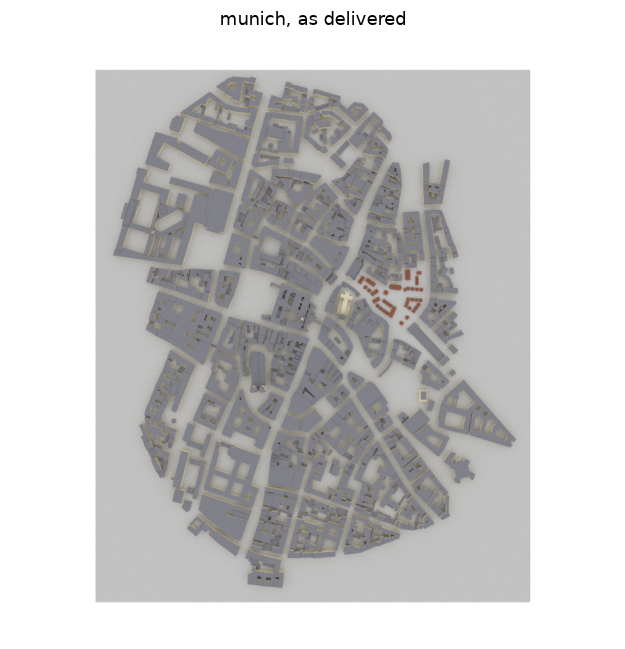

In [7]:
from src.simulation import scene as scene_module
from src.simulation.scene import SceneSpec

delivered_scene, delivered = scene_module.load(SceneSpec.from_config(cfg))
camera = top_down_camera(delivered)

render(delivered_scene, camera, f"{cfg.simulation.scene.name}, as delivered", name="scene_delivered")

## 3. Schema — the artifacts against the config

What is actually in the files, versus what `configs/simulation.yaml` declares.
Any gap found here is a change to the config, not a fix applied in code.

In [8]:
ue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9939 entries, 0 to 9938
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   t_index    9939 non-null   int64  
 1   t_s        9939 non-null   float64
 2   x          9939 non-null   float64
 3   y          9939 non-null   float64
 4   z          9939 non-null   float64
 5   tile_col   9939 non-null   int64  
 6   tile_row   9939 non-null   int64  
 7   component  9939 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 621.3 KB


In [9]:
print(f"mdt position columns  ({len(position_columns)}): {position_columns}")
print(f"mdt measurement columns ({len(measurement_columns)}): {measurement_columns[:4]} ...")
mdt.dtypes.value_counts().to_frame("columns")

mdt position columns  (7): ['t_index', 't_s', 'x', 'y', 'z', 'tile_col', 'tile_row']
mdt measurement columns (36): ['rsrp_n0c0_b2600', 'rsrp_n0c0_b1800', 'rsrp_n0c0_b700', 'rsrp_n0c1_b2600'] ...


,columns
float64,40
int64,3


In [10]:
pd.DataFrame(
    [
        {"key": key, "shape": str(value.shape), "dtype": str(value.dtype)}
        for key, value in radio.items()
    ]
)

,key,shape,dtype
0,rsrp_dbm,"(3, 12, 61, 74)",float32
1,band_hz,"(3,)",float64
2,band_label,"(3,)",<U5
3,tilt_deg,"(3, 12)",float64
4,tx_name,"(12,)",<U4
5,origin_x,(),float64
6,origin_y,(),float64
7,tile_size_m,(),float64
8,n_cols,(),int64
9,n_rows,(),int64


In [11]:
configured_tx = [str(entry.name) for entry in cfg.simulation.transmitters.cells]
configured_bands = [str(entry.name) for entry in cfg.simulation.radio_map.bands]
# mdt.py names the measurement columns tx-major, band-minor.
expected_columns = [f"rsrp_{tx}_{band}" for tx in tx_names for band in bands]
grid_meta = manifest["grid"]

schema_checks = pd.DataFrame(
    [
        ("npz tx_name matches the configured cells", tx_names == configured_tx),
        ("npz band_label matches the configured bands", bands == configured_bands),
        ("mdt measurement columns are tx x band", measurement_columns == expected_columns),
        ("npz scenario_id matches the manifest", str(radio["scenario_id"]) == manifest["scenario_id"]),
        (
            "npz grid matches the manifest grid",
            (n_rows, n_cols, tile_size, origin_x, origin_y)
            == (
                grid_meta["n_rows"],
                grid_meta["n_cols"],
                grid_meta["tile_size_m"],
                grid_meta["origin_x"],
                grid_meta["origin_y"],
            ),
        ),
        ("npz ue_height_m matches the config", float(radio["ue_height_m"]) == float(cfg.simulation.ue.height_m)),
        ("mdt is row-aligned with ue_positions", len(mdt) == len(ue)),
    ],
    columns=["check", "holds"],
)
save_table(schema_checks, "schema_checks")
schema_checks


,check,holds
0,npz tx_name matches the configured cells,True
1,npz band_label matches the configured bands,True
2,mdt measurement columns are tx x band,True
3,npz scenario_id matches the manifest,True
4,npz grid matches the manifest grid,True
5,npz ue_height_m matches the config,True
6,mdt is row-aligned with ue_positions,False


The last check fails by design: `mdt.build` drops UEs no transmitter reaches, so
the MDT is shorter than the UE table and the two cannot be joined by row order.
Section 4 quantifies the gap.

## 4. Missingness

Two different kinds, and the files do not label them the same way.

- `rsrp_dbm` is NaN where the ray tracer found **no path**. That is a physical
  fact about the geometry, not a gap.
- An `rsrp_*` cell in the MDT is empty where there was no path **or** where the
  handset did not report it. The file cannot tell the two apart.

Imputation itself happens in `02x`, fitted on train only.

In [12]:
pd.DataFrame(np.isfinite(rsrp).mean(axis=(2, 3)).T, index=tx_names, columns=bands)

,b2600,b1800,b700
n0c0,0.375055,0.370846,0.371511
n0c1,0.373283,0.373283,0.372397
n0c2,0.375498,0.371954,0.372840
n1c0,0.293753,0.289322,0.291759
n1c1,0.290873,0.288214,0.290651
n1c2,0.290651,0.288436,0.289765
n2c0,0.347807,0.350244,0.347364
n2c1,0.348471,0.354674,0.350244
n2c2,0.352459,0.352681,0.350244
n3c0,0.352459,0.341604,0.347585


In [13]:
reach_by_band = pd.DataFrame(
    {
        "map_cells_with_a_path": np.isfinite(rsrp).mean(axis=(1, 2, 3)),
        "cells_reached_by_any_tx": np.isfinite(best_server).mean(axis=(1, 2)),
        "mdt_reported": [
            mdt[[c for c in measurement_columns if c.endswith(f"_{band}")]]
            .notna()
            .to_numpy()
            .mean()
            for band in bands
        ],
    },
    index=bands,
)
save_table(reach_by_band.rename_axis("band").reset_index(), "reach_by_band")
reach_by_band


,map_cells_with_a_path,cells_reached_by_any_tx,mdt_reported
b2600,0.341235,0.908728,0.286809
b1800,0.338521,0.904076,0.285778
b700,0.339610,0.909171,0.312511


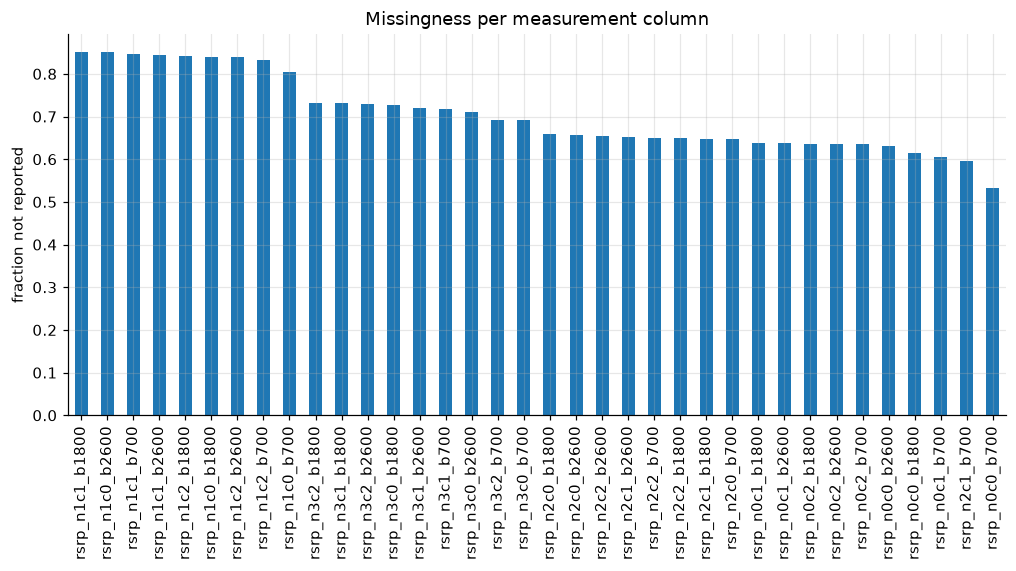

,missing_fraction
count,36.000000
mean,0.704967
std,0.089102
min,0.532007
25%,0.638362
50%,0.674724
75%,0.750722
max,0.850531


In [14]:
missing = mdt[measurement_columns].isna().mean().sort_values(ascending=False)

figure, axis = plt.subplots(figsize=(11.0, 4.5))
missing.plot.bar(ax=axis)
axis.set_ylabel("fraction not reported")
axis.set_title("Missingness per measurement column")
save_fig(figure, "missingness_per_column")
plt.show()

missing.describe().to_frame("missing_fraction")

ue_positions 9,939 rows, mdt 9,701 rows — 238 UEs (2.4%) heard nothing and were dropped


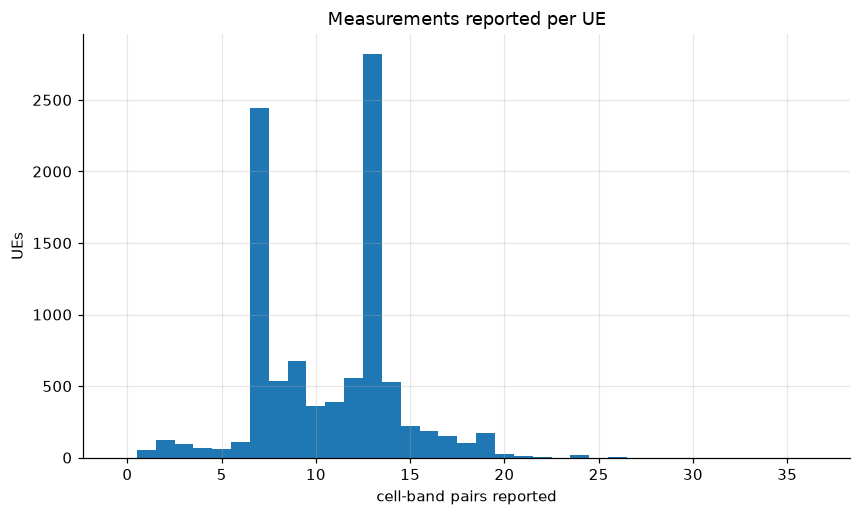

In [15]:
print(
    f"ue_positions {len(ue):,} rows, mdt {len(mdt):,} rows — "
    f"{len(ue) - len(mdt):,} UEs ({(len(ue) - len(mdt)) / len(ue):.1%}) heard nothing and were dropped"
)

reported = mdt[measurement_columns].notna()

figure, axis = plt.subplots()
axis.hist(reported.sum(axis=1), bins=np.arange(len(measurement_columns) + 2) - 0.5)
axis.set_xlabel("cell-band pairs reported")
axis.set_ylabel("UEs")
axis.set_title("Measurements reported per UE")
save_fig(figure, "measurements_reported_per_ue")
plt.show()

## 5. Univariate distributions

Shape, scale, skew, and suspicious spikes. A spike at a round number, at zero, or
at a sensor's range limit is usually an encoded missing value in disguise.

In [16]:
ue.describe().T

,count,mean,std,min,25%,50%,75%,max
t_index,9939.0,82.744542,48.259498,0.000,41.0000,81.000,126.0000,167.000
t_s,9939.0,297880.350136,173734.191398,0.000,147600.0000,291600.000,453600.0000,601200.000
x,9939.0,-6.250199,290.249315,-805.441,-219.2830,-29.715,186.0905,669.091
y,9939.0,-139.603278,294.204325,-687.555,-383.3145,-227.959,141.5880,511.250
z,9939.0,1.500000,0.000000,1.500,1.5000,1.500,1.5000,1.500
tile_col,9939.0,39.467049,14.511506,0.000,29.0000,38.000,49.0000,73.000
tile_row,9939.0,26.952410,14.707733,0.000,15.0000,23.000,41.0000,59.000
component,9939.0,1.294195,1.306815,-1.000,0.0000,1.000,2.0000,3.000


In [17]:
mdt[position_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
t_index,9701.0,82.786105,48.215138,0.000,42.000,81.000,126.000,167.000
t_s,9701.0,298029.976291,173574.495657,0.000,151200.000,291600.000,453600.000,601200.000
x,9701.0,-7.793173,284.854283,-805.441,-217.453,-30.855,178.197,669.091
y,9701.0,-142.165077,296.145356,-687.555,-386.614,-243.520,142.027,511.250
z,9701.0,1.500000,0.000000,1.500,1.500,1.500,1.500,1.500
tile_col,9701.0,39.389547,14.240942,0.000,29.000,38.000,49.000,73.000
tile_row,9701.0,26.824142,14.804666,0.000,15.000,22.000,41.000,59.000


In [18]:
pd.DataFrame(
    {
        "best_server_map": pd.Series(best_server.ravel()).describe(),
        "reported_mdt": pd.Series(mdt[measurement_columns].to_numpy().ravel()).describe(),
    }
)

,best_server_map,reported_mdt
count,12287.000000,103036.00000
mean,-81.552605,-106.83981
std,18.547541,23.63639
min,-201.329437,-204.94300
25%,-90.008026,-124.02500
50%,-78.792831,-108.26100
75%,-68.896896,-88.82375
max,-44.410389,-42.84100


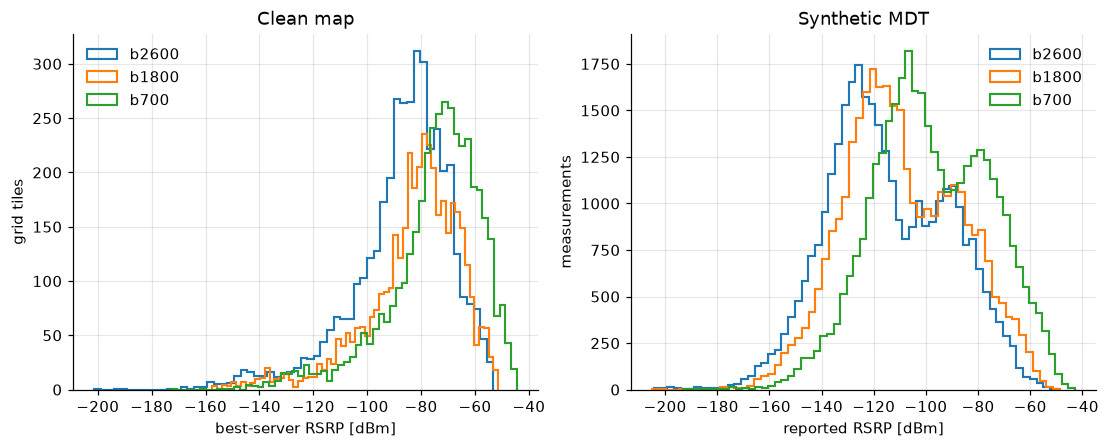

In [19]:
figure, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))
for index, band in enumerate(bands):
    values = best_server[index]
    axes[0].hist(values[np.isfinite(values)], bins=60, histtype="step", lw=1.4, label=band)
    columns = [column for column in measurement_columns if column.endswith(f"_{band}")]
    observed = mdt[columns].to_numpy().ravel()
    axes[1].hist(observed[np.isfinite(observed)], bins=60, histtype="step", lw=1.4, label=band)
axes[0].set_xlabel("best-server RSRP [dBm]")
axes[0].set_ylabel("grid tiles")
axes[0].set_title("Clean map")
axes[1].set_xlabel("reported RSRP [dBm]")
axes[1].set_ylabel("measurements")
axes[1].set_title("Synthetic MDT")
for axis in axes:
    axis.legend()
save_fig(figure, "rsrp_distributions_clean_vs_mdt")
plt.show()

## 6. Group structure

**This section decides how the data is split.**

The intended split unit is the **scenario** — one drawn city plus the people in
it. A scenario is regenerated from its `scenario_id`, and train/validation/test
are meant to be split between whole scenarios so that no two rows sharing a city
straddle the boundary.

In [20]:
per_interval = ue.groupby("t_index").size()
per_tile = ue.groupby(["tile_row", "tile_col"]).size()

pd.DataFrame(
    {
        "value": {
            "scenarios on disk": 1,
            "scenario_id": manifest["scenario_id"],
            "intervals": int(ue["t_index"].nunique()),
            "rows per interval (mean)": round(per_interval.mean(), 1),
            "grid tiles occupied": int(per_tile.size),
            "grid tiles total": n_rows * n_cols,
            "rows per occupied tile (mean)": round(per_tile.mean(), 1),
            "rows per occupied tile (max)": int(per_tile.max()),
        }
    }
)

,value
scenarios on disk,1
scenario_id,scn_b2779850236462be
intervals,168
rows per interval (mean),59.2
grid tiles occupied,2355
grid tiles total,4514
rows per occupied tile (mean),4.2
rows per occupied tile (max),52


One scenario is on disk, so a between-scenario split is not yet possible — that
is a blocker for notebook 02, not a choice it can make.

Within the scenario, UEs are redrawn every interval and land repeatedly in the
same grid tiles, and every UE in a tile reads the *same* radio-map values. A
random row split would therefore put near-duplicate rows on both sides.

## 7. Relationships

What is worth modelling, and what is too predictive to be real. The MDT is
*derived* from the radio map, so predicting the map from the MDT is circular by
construction — the interesting question is how much the noise and censoring
destroy, which is what the residual below measures.

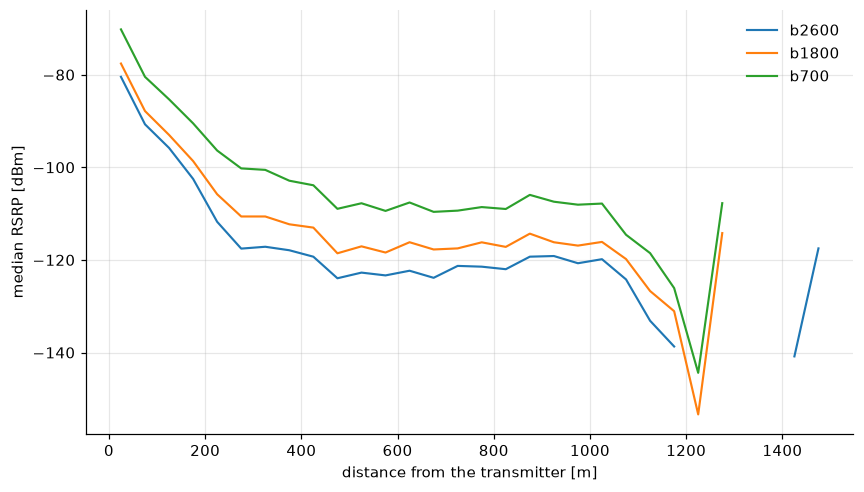

In [21]:
xs = origin_x + (np.arange(n_cols) + 0.5) * tile_size
ys = origin_y + (np.arange(n_rows) + 0.5) * tile_size
grid_x, grid_y = np.meshgrid(xs, ys)
distance = np.stack(
    [np.hypot(grid_x - row.x, grid_y - row.y) for row in cells.itertuples()]
)
edges = np.arange(0.0, distance.max() + 50.0, 50.0)
midpoints = 0.5 * (edges[:-1] + edges[1:])

figure, axis = plt.subplots()
for index, band in enumerate(bands):
    finite = np.isfinite(rsrp[index])
    which = np.digitize(distance[finite], edges) - 1
    values = rsrp[index][finite]
    median = [
        np.median(values[which == bin_index]) if np.any(which == bin_index) else np.nan
        for bin_index in range(len(edges) - 1)
    ]
    axis.plot(midpoints, median, lw=1.4, label=band)
axis.set_xlabel("distance from the transmitter [m]")
axis.set_ylabel("median RSRP [dBm]")
axis.legend()
save_fig(figure, "path_loss_by_band")
plt.show()

reported minus clean: mean +0.010 dB, sd 2.003 dB (configured rsrp_noise_sigma_db = 2.0)


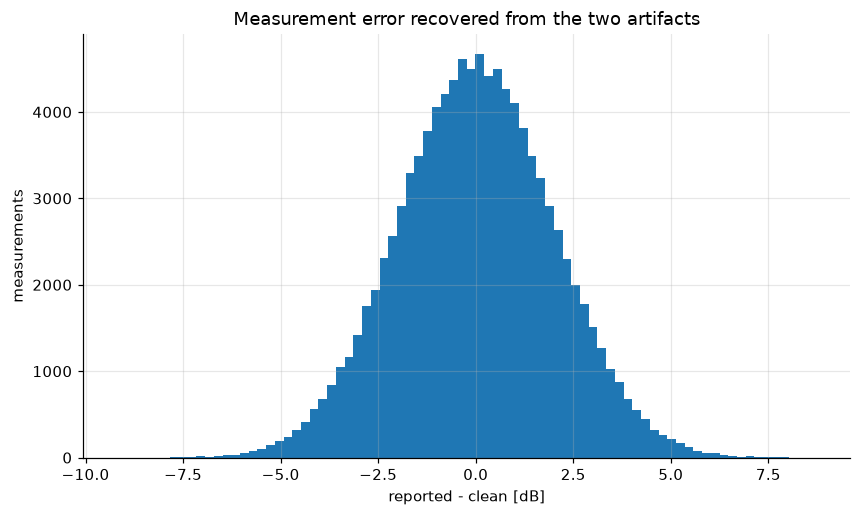

In [22]:
row = mdt["tile_row"].to_numpy()
col = mdt["tile_col"].to_numpy()
# [band, tx, ue] -> [ue, tx, band] -> flattened tx-major, band-minor, matching mdt.
clean = rsrp[:, :, row, col].transpose(2, 1, 0).reshape(len(mdt), -1).astype(np.float64)
observed = mdt[measurement_columns].to_numpy()
both = np.isfinite(clean) & np.isfinite(observed)
residual = observed[both] - clean[both]

print(
    f"reported minus clean: mean {residual.mean():+.3f} dB, sd {residual.std():.3f} dB "
    f"(configured rsrp_noise_sigma_db = {cfg.simulation.mdt.rsrp_noise_sigma_db})"
)

figure, axis = plt.subplots()
axis.hist(residual, bins=80)
axis.set_xlabel("reported - clean [dB]")
axis.set_ylabel("measurements")
axis.set_title("Measurement error recovered from the two artifacts")
save_fig(figure, "measurement_error_residual")
plt.show()

In [23]:
pd.DataFrame(
    {band: pd.Series(np.where(np.isfinite(best_server[index]), best_server[index], np.nan).ravel())
     for index, band in enumerate(bands)}
).corr()

,b2600,b1800,b700
b2600,1.000000,0.931029,0.957843
b1800,0.931029,1.000000,0.958886
b700,0.957843,0.958886,1.000000


In [24]:
first_band = [column for column in measurement_columns if column.endswith(f"_{bands[0]}")]
mdt[first_band].corr().round(2)

,rsrp_n0c0_b2600,rsrp_n0c1_b2600,rsrp_n0c2_b2600,rsrp_n1c0_b2600,rsrp_n1c1_b2600,rsrp_n1c2_b2600,rsrp_n2c0_b2600,rsrp_n2c1_b2600,rsrp_n2c2_b2600,rsrp_n3c0_b2600,rsrp_n3c1_b2600,rsrp_n3c2_b2600
rsrp_n0c0_b2600,1.00,0.02,0.41,-0.36,-0.29,-0.24,0.30,-0.09,0.47,-0.41,-0.34,-0.12
rsrp_n0c1_b2600,0.02,1.00,0.54,-0.23,0.20,0.52,-0.01,-0.32,-0.13,0.16,-0.06,0.15
rsrp_n0c2_b2600,0.41,0.54,1.00,-0.22,-0.19,0.21,0.14,-0.21,0.20,-0.00,-0.07,0.12
rsrp_n1c0_b2600,-0.36,-0.23,-0.22,1.00,0.39,0.16,-0.29,-0.71,-0.61,0.07,0.62,-0.15
rsrp_n1c1_b2600,-0.29,0.20,-0.19,0.39,1.00,0.63,0.27,-0.30,-0.17,-0.05,0.45,-0.16
rsrp_n1c2_b2600,-0.24,0.52,0.21,0.16,0.63,1.00,-0.12,-0.08,0.07,0.04,0.31,-0.42
rsrp_n2c0_b2600,0.30,-0.01,0.14,-0.29,0.27,-0.12,1.00,0.11,0.54,-0.12,-0.49,-0.54
rsrp_n2c1_b2600,-0.09,-0.32,-0.21,-0.71,-0.30,-0.08,0.11,1.00,0.22,-0.62,-0.27,-0.27
rsrp_n2c2_b2600,0.47,-0.13,0.20,-0.61,-0.17,0.07,0.54,0.22,1.00,-0.20,-0.38,-0.50
rsrp_n3c0_b2600,-0.41,0.16,-0.00,0.07,-0.05,0.04,-0.12,-0.62,-0.20,1.00,0.24,-0.05


## 8. Temporal and spatial structure

Every interval draws a fresh crowd from the same hotspots with time-varying
mixture mass, so the UE distribution moves while the city and the radio map stay
put. The panels below are consecutive intervals over a short window; crosses mark
the hotspot centres and triangles the cells.

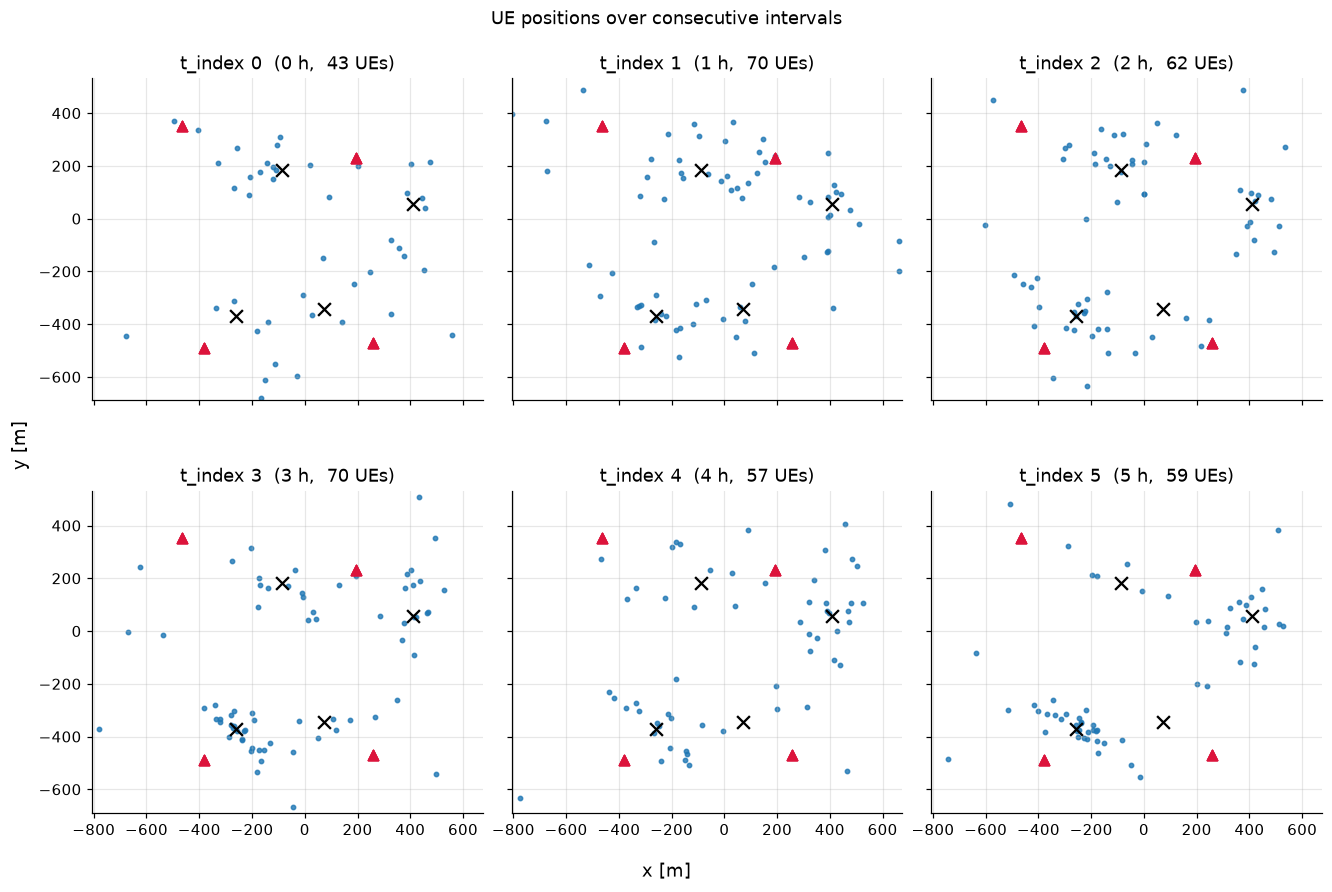

In [25]:
T_WINDOW = list(range(6))
PANEL_COLUMNS = 3

panel_rows = int(np.ceil(len(T_WINDOW) / PANEL_COLUMNS))
figure, axes = plt.subplots(
    panel_rows,
    PANEL_COLUMNS,
    figsize=(4.0 * PANEL_COLUMNS, 4.0 * panel_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for axis, t_index in zip(np.ravel(axes), T_WINDOW):
    part = ue[ue["t_index"] == t_index]
    axis.scatter(part["x"], part["y"], s=8, alpha=0.8)
    axis.scatter(hotspots["x"], hotspots["y"], marker="x", s=70, color="black", zorder=4)
    axis.scatter(cells["x"], cells["y"], marker="^", s=45, color="crimson", zorder=3)
    axis.set_xlim(extent[0], extent[1])
    axis.set_ylim(extent[2], extent[3])
    axis.set_aspect("equal")
    hours_in = part["t_s"].iloc[0] / 3600.0 if len(part) else float("nan")
    axis.set_title(f"t_index {t_index}  ({hours_in:.0f} h,  {len(part)} UEs)")
for axis in np.ravel(axes)[len(T_WINDOW):]:
    axis.set_visible(False)
figure.supxlabel("x [m]")
figure.supylabel("y [m]")
figure.suptitle("UE positions over consecutive intervals")
save_fig(figure, "ue_positions_time_window")
plt.show()

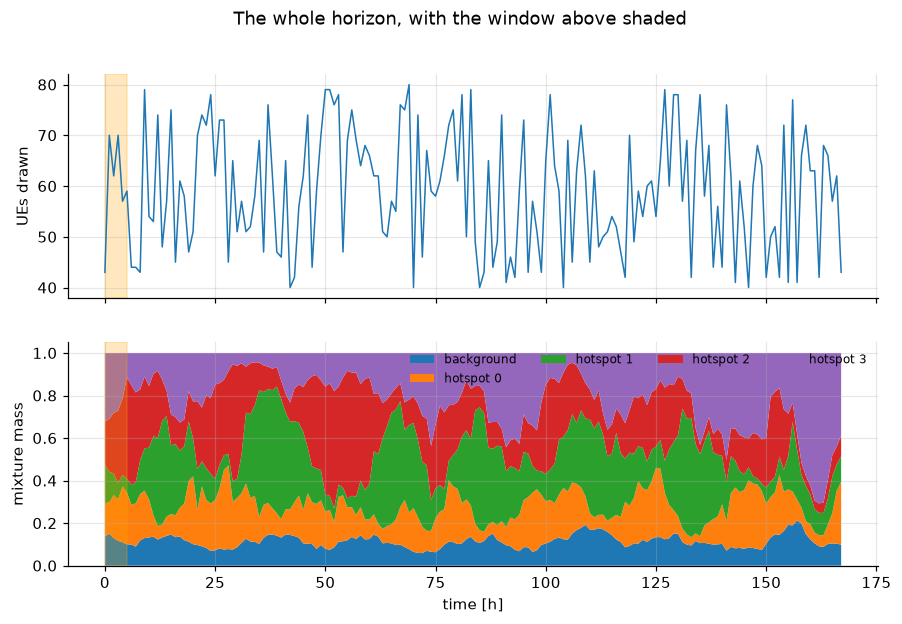

In [26]:
per_time = ue.groupby("t_s").size()
mass = np.asarray(manifest["time"]["component_mass"])
hours = np.asarray(manifest["time"]["t_s"]) / 3600.0

figure, axes = plt.subplots(2, 1, figsize=(9.5, 5.8), sharex=True)
axes[0].plot(per_time.index / 3600.0, per_time.to_numpy(), lw=1.0)
axes[0].set_ylabel("UEs drawn")
axes[1].stackplot(
    hours,
    mass.T,
    labels=["background"] + [f"hotspot {index}" for index in range(mass.shape[1] - 1)],
)
axes[1].set_ylabel("mixture mass")
axes[1].set_xlabel("time [h]")
axes[1].legend(loc="upper right", ncol=4, fontsize=8)
for axis in axes:
    axis.axvspan(hours[T_WINDOW[0]], hours[T_WINDOW[-1]], color="orange", alpha=0.25)
figure.suptitle("The whole horizon, with the window above shaded")
save_fig(figure, "time_schedule_full_horizon")
plt.show()

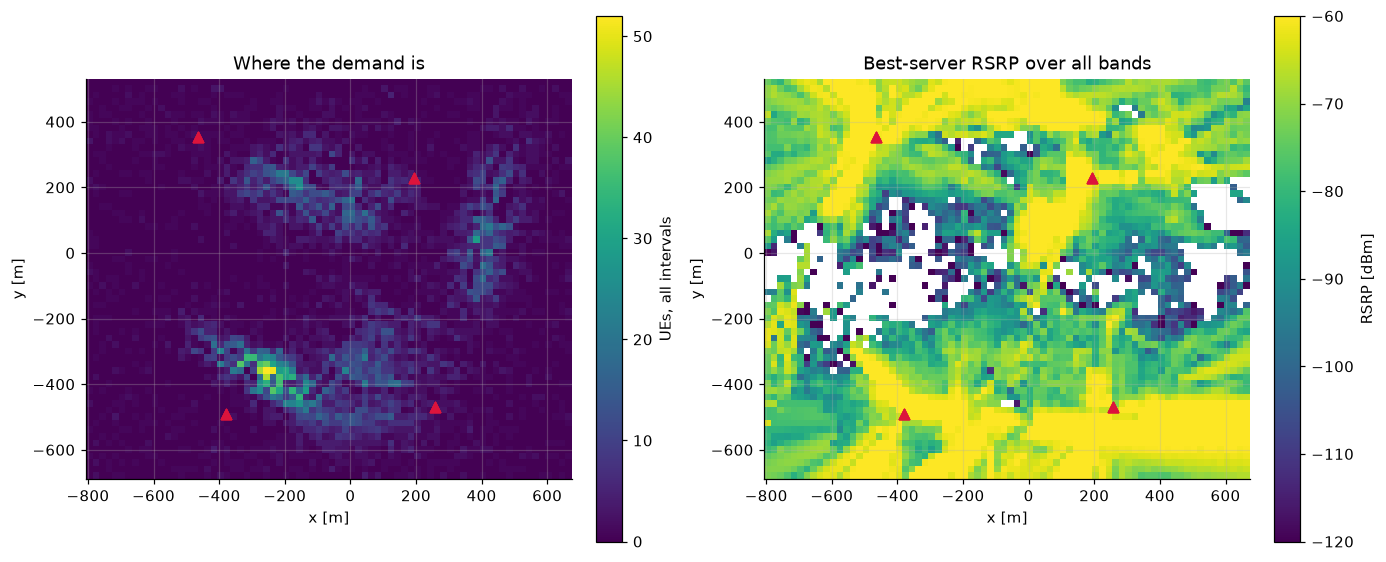

In [27]:
counts = np.zeros((n_rows, n_cols))
np.add.at(counts, (ue["tile_row"].to_numpy(), ue["tile_col"].to_numpy()), 1.0)
overall = np.where(np.isfinite(best_server), best_server, np.nan).max(axis=0)

figure, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), constrained_layout=True)
for axis, values, label, title in (
    (axes[0], counts, "UEs, all intervals", "Where the demand is"),
    (axes[1], overall, "RSRP [dBm]", "Best-server RSRP over all bands"),
):
    limits = {} if label.startswith("UEs") else {"vmin": -120.0, "vmax": -60.0}
    image = axis.imshow(values, origin="lower", extent=extent, aspect="equal", **limits)
    figure.colorbar(image, ax=axis, label=label)
    axis.scatter(cells["x"], cells["y"], marker="^", s=45, color="crimson", zorder=3)
    axis.set_xlabel("x [m]")
    axis.set_ylabel("y [m]")
    axis.set_title(title)
save_fig(figure, "demand_vs_coverage")
plt.show()

Demand is drawn towards densely built ground, which is also where propagation is
worst. That tension between the two panels is the problem the project is about.

## 9. Data quality issues and candidate hard constraints

The output of this section feeds directly into notebook 02.

For every filter proposed, the **external source** of the bound is written down.
Where no source can be named, it is a statistical threshold and belongs in `02x`,
fitted on train only.

The KPI thresholds below *classify* a tile; they do not filter a row. They are
listed here because notebook 02 must not silently drop the tiles they describe.

In [28]:
area = manifest["area"]
values = mdt[measurement_columns].to_numpy()
finite = values[np.isfinite(values)]

constraint_violations = pd.DataFrame(
    [
        (
            "ue.z == ue.height_m",
            "configs/simulation.yaml simulation.ue.height_m",
            int((ue["z"] != float(cfg.simulation.ue.height_m)).sum()),
        ),
        (
            "0 <= tile_row < n_rows",
            "manifest grid",
            int(((ue["tile_row"] < 0) | (ue["tile_row"] >= grid_meta["n_rows"])).sum()),
        ),
        (
            "0 <= tile_col < n_cols",
            "manifest grid",
            int(((ue["tile_col"] < 0) | (ue["tile_col"] >= grid_meta["n_cols"])).sum()),
        ),
        (
            "x within the region of interest",
            "manifest area",
            int(((ue["x"] < area["min_x"]) | (ue["x"] > area["max_x"])).sum()),
        ),
        (
            "y within the region of interest",
            "manifest area",
            int(((ue["y"] < area["min_y"]) | (ue["y"] > area["max_y"])).sum()),
        ),
        (
            "reported RSRP <= the transmit reference-signal power",
            "configs/simulation.yaml simulation.antenna.power_rs",
            int((finite > float(cfg.simulation.antenna.power_rs)).sum()),
        ),
        (
            "reported RSRP <= -120 dBm (hole threshold)",
            "docs/adr/0001-five-kpis-under-lexicographic-priority.md",
            int((finite <= -120.0).sum()),
        ),
        (
            "-120 < reported RSRP <= -90 dBm (weak threshold)",
            "docs/adr/0001-five-kpis-under-lexicographic-priority.md",
            int(((finite > -120.0) & (finite <= -90.0)).sum()),
        ),
    ],
    columns=["rule", "source", "records affected"],
)
save_table(constraint_violations, "constraint_violations")
constraint_violations


,rule,source,records affected
0,ue.z == ue.height_m,configs/simulation.yaml simulation.ue.height_m,0
1,0 <= tile_row < n_rows,manifest grid,0
2,0 <= tile_col < n_cols,manifest grid,0
3,x within the region of interest,manifest area,0
4,y within the region of interest,manifest area,0
5,reported RSRP <= the transmit reference-signal...,configs/simulation.yaml simulation.antenna.pow...,0
6,reported RSRP <= -120 dBm (hole threshold),docs/adr/0001-five-kpis-under-lexicographic-pr...,32371
7,-120 < reported RSRP <= -90 dBm (weak threshold),docs/adr/0001-five-kpis-under-lexicographic-pr...,43392


In [29]:
coverage = np.where(np.isfinite(best_server), best_server, -np.inf)

coverage_rate_by_band = pd.DataFrame(
    {
        "hole_rate": (coverage <= -120.0).mean(axis=(1, 2)),
        "weak_rate": ((coverage > -120.0) & (coverage <= -90.0)).mean(axis=(1, 2)),
        "good_rate": (coverage > -90.0).mean(axis=(1, 2)),
    },
    index=bands,
)
save_table(coverage_rate_by_band.rename_axis("band").reset_index(), "coverage_rate_by_band")
coverage_rate_by_band


,hole_rate,weak_rate,good_rate
b2600,0.144440,0.256092,0.599468
b1800,0.132255,0.195392,0.672353
b700,0.118963,0.112096,0.768941


## 10. Findings — what 02 and 02x must do

**Blocker.** One scenario is on disk. The intended between-scenario split cannot
be made until `task simulation` has been run for several seeds. Until then any
split is within-scenario and optimistic.

**For notebook 02 (deterministic, model-agnostic):**
- Split unit: `scenario_id` from the manifest. Within a scenario, `t_index` is
  the coarsest honest fallback — never a random row split, because UEs repeat
  tiles and every UE in a tile reads the same radio-map values.
- Join key: `ue_positions.csv` and `mdt.csv` are **not** row-aligned; join on
  `(t_index, x, y)` or regenerate, never on row order.
- Empty `rsrp_*` in the MDT means *no path or censored* and must not be read as
  zero. Carry an explicit "reported" indicator alongside every value.
- Hard constraints: the rows in section 10 whose source is the manifest or the
  config. The KPI thresholds classify tiles and must not be used to drop rows.
- Drop nothing on the strength of the −120/−90 dBm thresholds: holes are the
  measurement, not the defect.

**For the `02x` notebooks (learned from train only):**
- Missing values: the measurement columns, with censoring modelled rather than
  imputed — the drop is by design and its rate is known.
- Scaling: RSRP is already in dB and roughly linear in log-distance; centring per
  band is likely enough.
- Feature ideas: distance and bearing to each cell, the cell's tilt on that
  band, and local built volume from the raster.

**Open questions:**
- How many scenarios are needed before a between-scenario split is stable?
- Does the surrogate predict the clean map per cell-band, or the KPI vector
  directly? Section 8 shows the MDT is a censored view of the map, so the two
  targets need very different amounts of data.